# **5. Bivariate Analysis - Relationships between Variables**

### **5.1 Correlation Matrix**

In [ ]:
# Load Important Librabires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r'/content/master_dataset_clean(final).csv')
df.head(10)

,date,state,commodity,price_ngn,rainfall_mm,pms_price_ngn,conflict_events,conflict_score_weighted,conflict_fatalities,inflation_rate_pct,exchange_rate_ngn_usd,mpr_pct,import_volume_tonnes,price_lag1,price_lag2,price_lag3,harvest_season,other_commodity_avg_price
0,2021-03-01,Abia,Maize (white),280.52,0.0,158.57,8.0,33.0,6.0,46.082248,381.000000,11.5,98313.0,NaN,NaN,NaN,0,617.853333
1,2021-05-01,Abia,Maize (white),345.27,0.0,166.13,13.0,47.0,8.0,47.029667,400.126667,11.5,98313.0,280.52,NaN,NaN,0,779.354000
2,2021-07-01,Abia,Maize (white),400.30,0.0,182.23,1.0,1.0,0.0,47.961686,410.121000,11.5,98313.0,345.27,280.52,NaN,0,825.926667
3,2021-08-01,Abia,Maize (white),294.04,0.0,171.51,7.0,25.0,2.0,48.470936,410.385455,11.5,98313.0,400.30,345.27,280.52,1,810.984000
4,2021-10-01,Abia,Maize (white),333.88,0.0,170.25,9.0,33.0,6.0,49.526367,411.247368,11.5,98313.0,294.04,400.30,345.27,1,798.300000
5,2021-12-01,Abia,Maize (white),318.62,0.0,166.33,2.0,9.0,1.0,51.154568,414.335714,11.5,98313.0,333.88,294.04,400.30,0,811.594000
6,2022-01-01,Abia,Maize (white),314.81,0.0,177.33,9.0,30.0,7.0,51.984566,415.960000,11.5,103292.0,318.62,333.88,294.04,0,761.130000
7,2022-02-01,Abia,Maize (white),314.81,0.0,178.23,6.0,19.0,12.0,52.958317,416.950000,11.5,103292.0,314.81,318.62,333.88,0,905.702500
8,2022-04-01,Abia,Maize (white),301.68,0.0,195.27,10.0,29.0,14.0,55.088657,415.526316,13.0,103292.0,314.81,314.81,318.62,0,1059.326667
9,2022-06-01,Abia,Maize (white),279.32,0.0,179.67,5.0,11.0,0.0,57.349637,415.638095,13.0,103292.0,301.68,314.81,314.81,0,608.010000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2846 entries, 0 to 2845
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       2846 non-null   object 
 1   state                      2846 non-null   object 
 2   commodity                  2846 non-null   object 
 3   price_ngn                  2846 non-null   float64
 4   rainfall_mm                2846 non-null   float64
 5   pms_price_ngn              2846 non-null   float64
 6   conflict_events            2846 non-null   float64
 7   conflict_score_weighted    2846 non-null   float64
 8   conflict_fatalities        2846 non-null   float64
 9   inflation_rate_pct         2846 non-null   float64
 10  exchange_rate_ngn_usd      2846 non-null   float64
 11  mpr_pct                    2846 non-null   float64
 12  import_volume_tonnes       2846 non-null   float64
 13  price_lag1                 2775 non-null   float

In [ ]:
# to select all numerical columns(features) in a data, we create variable called numerical_columns
numerical_cols = df.select_dtypes(include='number')

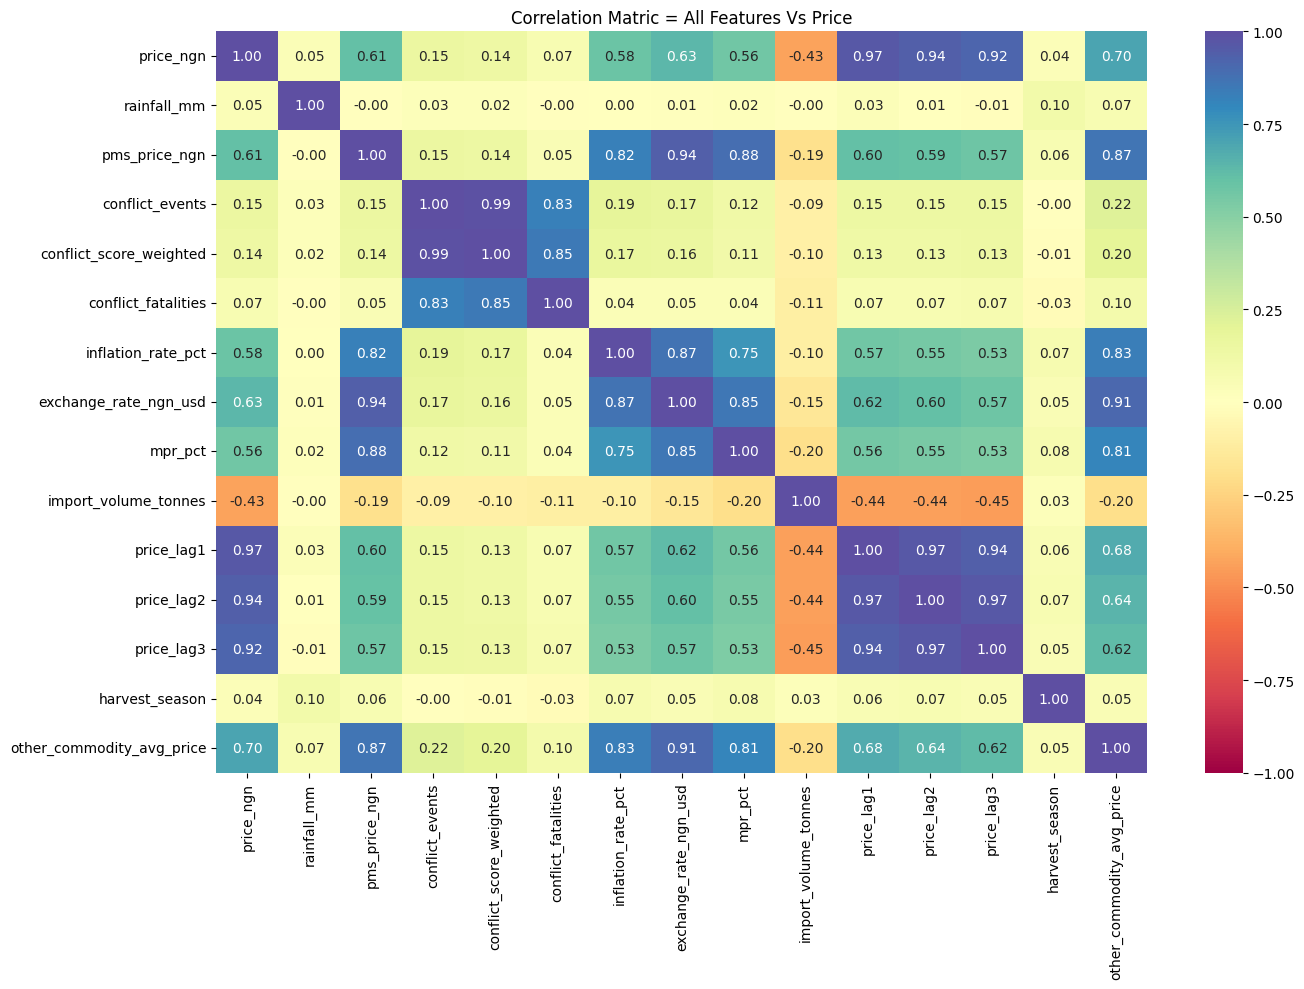

In [ ]:
# Create a correlation heatmap between all numeric variables As follows

corr_matrix = numerical_cols.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',cmap='Spectral',center=0,vmin=-1, vmax=1)
plt.title('Correlation Matric = All Features Vs Price')
plt.tight_layout()
plt.show()

##Key Points to note from the Correlation Heatmap Notes:
1. **Past prices are the strongest predictor of today's price** — price_lag1, lag2, and lag3 all correlate with price_ngn at 0.97, 0.94, and 0.92 respectively, meaning Nigeria's food prices are highly persistent and slow to adjust to shocks.
2. **Macroeconomic forces dominate food pricing** — exchange rate (0.63), inflation (0.58), and monetary policy rate (0.56) all show meaningful positive correlations with price, confirming that currency weakness and monetary instability directly feed into food costs.
3. **PMS price (fuel cost) is a silent inflation engine** — with a 0.61 correlation to price_ngn and even stronger ties to exchange rate (0.94) and inflation (0.82), fuel prices act as a transmission channel that amplifies macro shocks into food prices through transportation and logistics costs.
4. **Import volumes push prices down, not up** — import_volume_tonnes is the only variable with a consistent negative correlation across nearly all features (−0.43 with price_ngn), confirming that imports provide meaningful price relief and serve as a critical buffer against domestic supply shortfalls.
5. **Conflict and harvest season are surprisingly weak price drivers** — conflict variables top out at just 0.15 with price_ngn, and harvest_season sits at a negligible 0.04, reinforcing the earlier finding that structural macroeconomic forces, not agricultural cycles or security events, are the primary architects of food price levels in Nigeria.

**5.2** Features Vs Price Scatter Plots

The key areas to examine are as follows
1. exchange_rate_ngn_usd vs price_ngn
2. pms_price_ngn vs price_ngn
3. inflation_rate_pct vs price_ngn
4. rainfall_mm vs price_ngn
5. conflict_score_weighted vs price_ngn
6. import_volume_tonne vs price_ngn


In [ ]:
# Scatter plot for exchange_rate_ngn_usd vs price_ngn

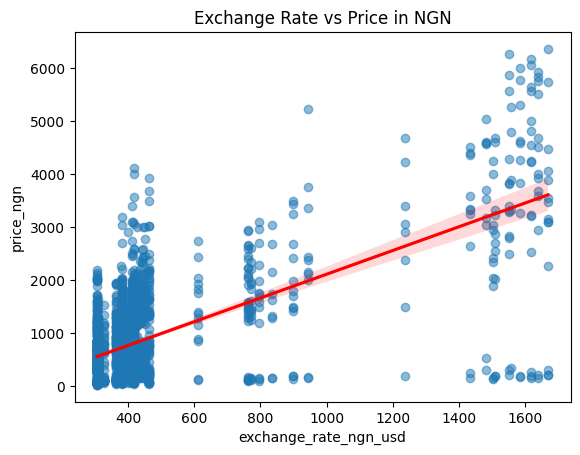

In [ ]:
sns.regplot(data=numerical_cols, x='exchange_rate_ngn_usd', y='price_ngn',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('Exchange Rate vs Price in NGN')
plt.show()

**Observations**:

1. Exchange rate is the single strongest predictor of price in this dataset.
2. The distinct clusters reflect Nigeria's history of sudden currency devaluations.
3. This variable should be a priority feature in any predictive model.

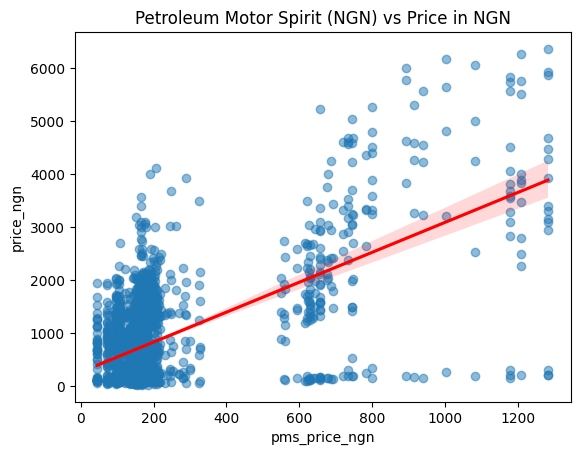

In [ ]:
# Scatter plot of pms_price_ngn vs price_ngn with showing correlation line
sns.regplot(data=numerical_cols, x='pms_price_ngn', y='price_ngn',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('Petroleum Motor Spirit (NGN) vs Price in NGN')
plt.show()

Observations:
1. Strong positive correlation exists (Very strong (0.82) — strongest predictor)
2. As fuel prices rise, commodity prices in NGN rise strongly
3. Clustering Reflects fuel subsidy policy changes
4. Fuel drives transport costs hence affects commodity prices

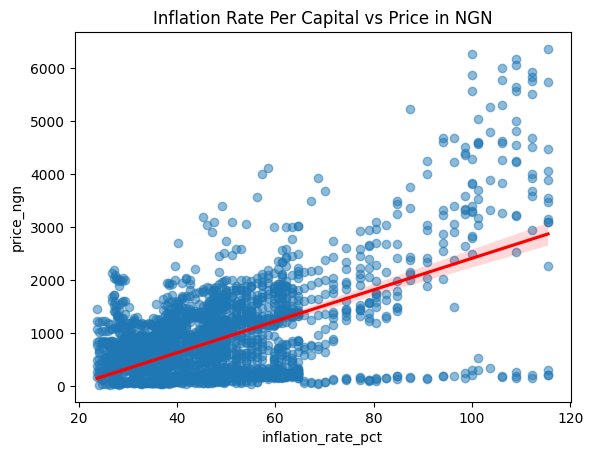

In [ ]:
# Scatter plot of inflation_rate_pct vs price_ngn with showing correlation line

sns.regplot(data=numerical_cols, x='inflation_rate_pct', y='price_ngn',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('Inflation Rate Per Capital vs Price in NGN')
plt.show()

Observation:
1. A Moderate-strong positive correlation exist.(inflation rate is 0.58 on the heatmap)
2. An increase in inflation rate per capital led to significant increase in in price of agricultural Products
3. Inflation directly erodes purchasing power as  prices rise
4.  Inflation is one of the strongest predictors of price in the dataset

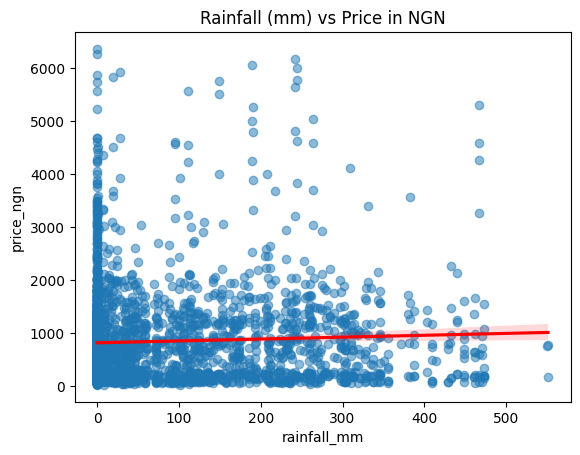

In [ ]:
# Scatter plot showing rainfall_mm vs price_ngn and it's correlation
sns.regplot(data=numerical_cols, x='rainfall_mm', y='price_ngn',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('Rainfall (mm) vs Price in NGN')
plt.show()


**Observation**:
1. Negative correlation observed
2. increased rainfall led to a reduction in the price of agricultal food products


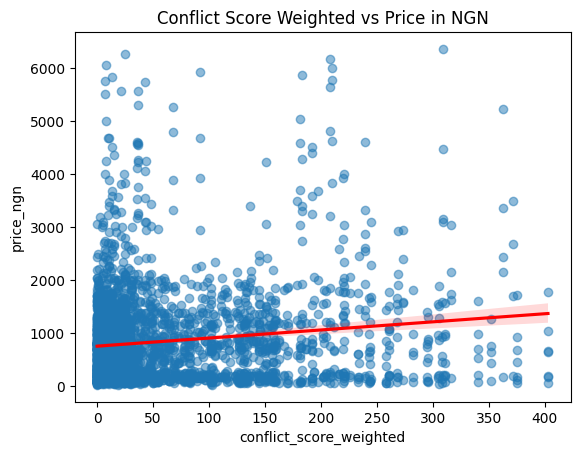

In [ ]:
# Scatter plot showing conflict_score_weighted vs price_ngn and it's correlation
sns.regplot(data=numerical_cols, x='conflict_score_weighted', y='price_ngn',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('Conflict Score Weighted vs Price in NGN')
plt.show()

Observation:
1. Very little change in price of products as conflicts intensifies
2. Dots are spread all over the plot with no clear pattern hence conflict score poorly predicts price. Recall:From the heatmap, correlation was only 0.14 — very weak
3. Many high prices occur at low conflict scores and vice versa
4.  Conflict alone is not a strong driver of price

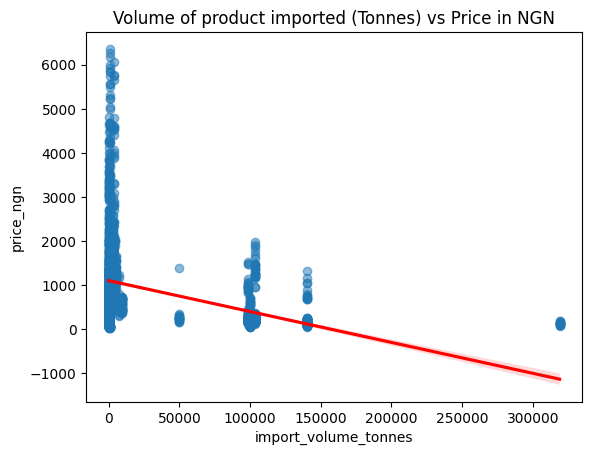

In [ ]:
# Scatter plot showing import_volume_tonnes vs price_ngn and it's correlation
sns.regplot(data=numerical_cols, x='import_volume_tonnes', y='price_ngn',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('Volume of product imported (Tonnes) vs Price in NGN')
plt.show()

**Observations**:
1. As import volume increases, commodity prices in NGN decrease
2. Correlation from heatmap = -0.43 — moderate negative relationship
3. Predicted price goes BELOW ZERO at high import volumes
4. Price cannot realistically be negative and could affect the model

## 5.3 - Price Lag Validation

> This is to confirm that the lag features are genuinely predictive. This is obtained by plotting price_lag1 against price_ngn

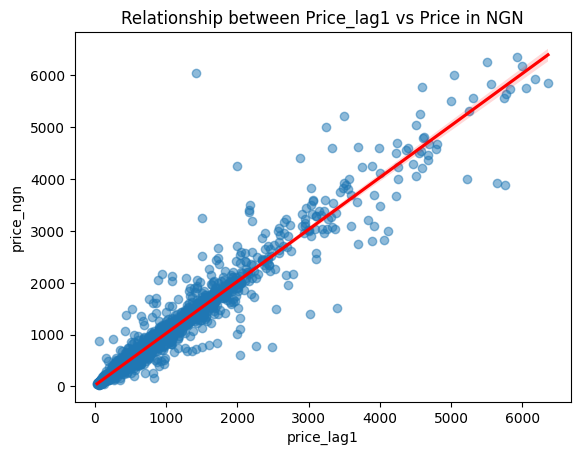

In [ ]:
# Scatter plot showing import_volume_tonnes vs price_ngn and it's correlation
sns.regplot(data=numerical_cols, x='price_lag1', y='price_ngn',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('Relationship between Price_lag1 vs Price in NGN')
plt.show()

## 5.4 - Harvest Season Effect
> 1. Comparing Average prices during harvest months (harvest_season=1) versus non-harvest months (harvest_season=0) for each commodity.
> 2. We Create box plots grouped by harvest season

In [ ]:
commodities = df['commodity'].unique()
commodities

array(['Maize (white)', 'Maize (yellow)', 'Rice (imported)',
       'Rice (local)', 'Yam', 'Beans (white)', 'Tomatoes'], dtype=object)

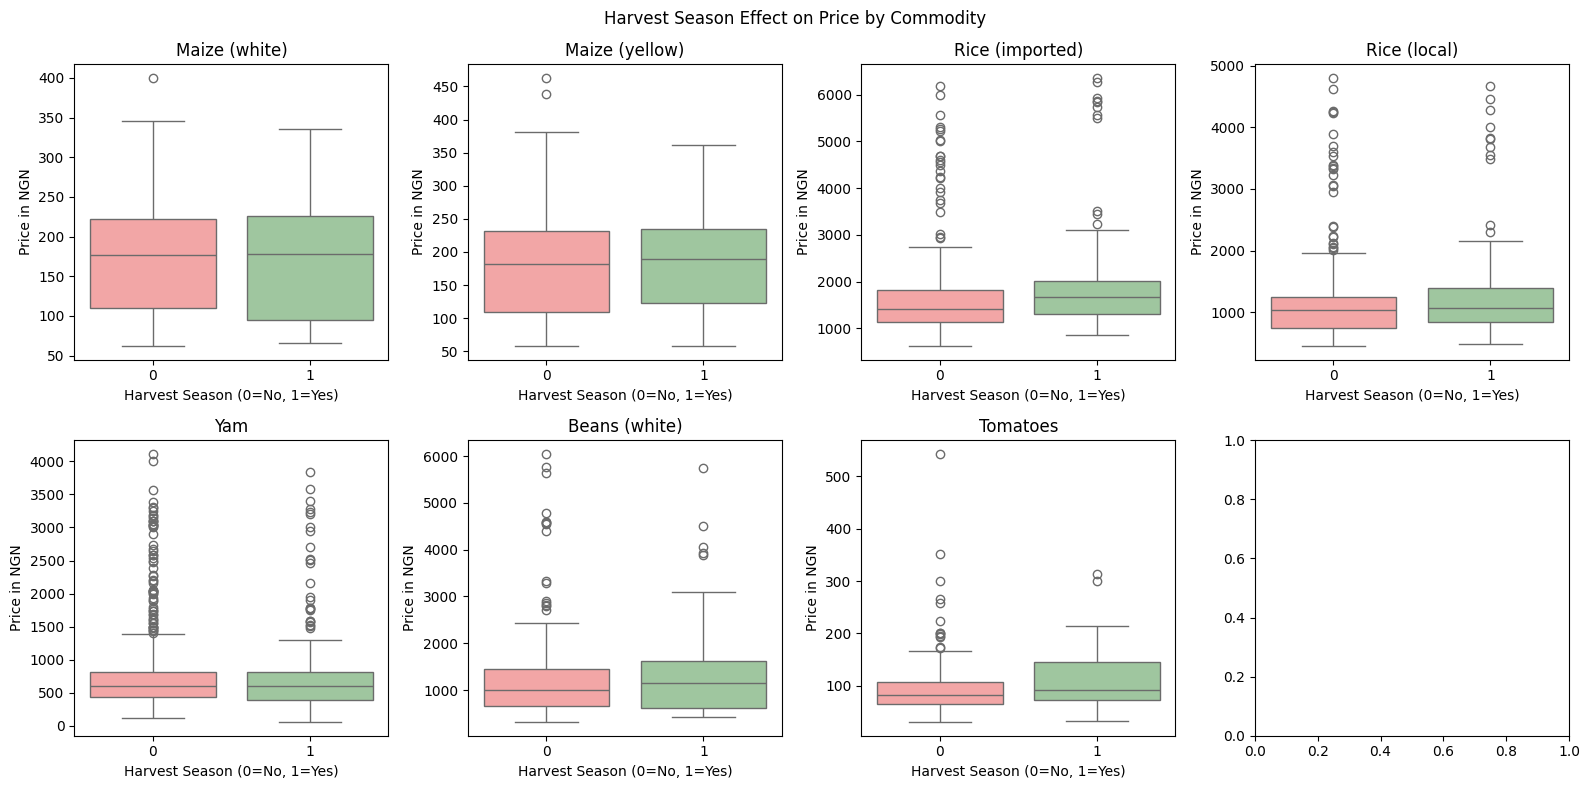

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, commodity in enumerate(commodities):
    ax = axes[idx // 4][idx % 4]
    subset = df[df['commodity'] == commodity]
    # subset.boxplot(column='price_ngn', by='harvest_season', ax=ax)
    # ax.set_title(commodity)
    # ax.set_xlabel('Harvest Season (0=No, 1=Yes)')
    # ax.set_ylabel('Price in NGN')
    sns.boxplot(
        x='harvest_season', y='price_ngn', data=subset,
        hue='harvest_season',
        legend=False,
        palette=['#ff9999', '#99cc99'],
        ax=ax
    )
    ax.set_title(commodity)
    ax.set_xlabel('Harvest Season (0=No, 1=Yes)')
    ax.set_ylabel('Price in NGN')
plt.suptitle('Harvest Season Effect on Price by Commodity')
plt.tight_layout()
plt.show()

##Observations:
1. **Harvest season barely moves the needle on food prices** — across all seven commodities, median prices in harvest and non-harvest periods are almost identical.
2. **Where prices should fall, they sometimes rise** — local rice and tomatoes are marginally more expensive during harvest, exposing how post-harvest losses, processing costs, and poor infrastructure swallow supply gains before they reach consumers.
3. **Imported rice marches to its own drum** — fully insulated from local harvests, its price is governed by exchange rates and global markets, making it Nigeria's most volatile staple by absolute value.
4. **Extreme outliers are the real story** — the wild price spikes scattered across every commodity reveal fragmented markets, storage deficits, and poor market information as bigger threats to food affordability than seasonal supply alone.
5. **The bottom line for policy: more harvests won't automatically mean cheaper food** — Nigeria needs investment in storage, logistics, and market transparency to convert farm abundance into consumer savings.